In [1]:
try:
    import pygeohash as pgh
except ImportError:
    !pip install pygeohash
    import pygeohash as pgh

import sys
import os
sys.path.append(r'C:\traffic-demand-final\pipelining\src')

import pandas as pd
import numpy as np
from config import *

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step03.csv'))
test_df = pd.read_csv(os.path.join(PROC_DIR, 'test_step03.csv'))

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

Train shape: (77299, 11)
Test shape: (41778, 10)


In [2]:
# Get unique geohashes from both train and test
unique_geohashes = set(train_df['geohash'].unique()).union(set(test_df['geohash'].unique()))

# Decode geohash to latitude and longitude
geohash_coords = {}
for gh in unique_geohashes:
    lat, lon = pgh.decode(gh)
    geohash_coords[gh] = (float(lat), float(lon))

# Map to train and test
train_df['latitude'] = train_df['geohash'].map(lambda x: geohash_coords[x][0])
train_df['longitude'] = train_df['geohash'].map(lambda x: geohash_coords[x][1])

test_df['latitude'] = test_df['geohash'].map(lambda x: geohash_coords[x][0])
test_df['longitude'] = test_df['geohash'].map(lambda x: geohash_coords[x][1])

print(train_df[['geohash', 'latitude', 'longitude']].head())

print("\nTrain Latitude - Min:", train_df['latitude'].min(), "Max:", train_df['latitude'].max(), "Mean:", train_df['latitude'].mean())
print("Train Longitude - Min:", train_df['longitude'].min(), "Max:", train_df['longitude'].max(), "Mean:", train_df['longitude'].mean())

  geohash  latitude  longitude
0  qp02z1 -5.484924  90.664673
1  qp02zt -5.462952  90.686646
2  qp08bj -5.462952  90.708618
3  qp08gt -5.462952  90.862427
4  qp02zq -5.457458  90.675659

Train Latitude - Min: -5.48492431640625 Max: -5.23773193359375 Mean: -5.348365191591408
Train Longitude - Min: 90.5877685546875 Max: 90.9722900390625 Mean: 90.76410822437214


### Conclusion

`pygeohash.decode()` converts a geohash string into its corresponding center latitude and longitude coordinates.
Adding latitude and longitude is valuable alongside target encoding because it allows the model to learn broader spatial relationships and continuous geographic patterns, whereas target encoding solely provides historical averages for discrete cells.
The coordinates suggest this dataset covers a relatively specific geographic region, as seen by the narrow range between min and max latitude and longitude values.

In [3]:
# Extract geohash prefix
train_df['geohash_prefix'] = train_df['geohash'].str[:GEOHASH_PREFIX_LEN]
test_df['geohash_prefix'] = test_df['geohash'].str[:GEOHASH_PREFIX_LEN]

unique_full = train_df['geohash'].nunique()
unique_prefix = train_df['geohash_prefix'].nunique()

print(f"Unique full geohash cells (Train): {unique_full}")
print(f"Unique geohash prefix cells (Train): {unique_prefix}")

print("\nTop 10 most common prefixes in Train:")
print(train_df['geohash_prefix'].value_counts().head(10))

Unique full geohash cells (Train): 1249
Unique geohash prefix cells (Train): 6

Top 10 most common prefixes in Train:
geohash_prefix
qp09    41391
qp03    23835
qp0d     6175
qp06     2511
qp08     1953
qp02     1434
Name: count, dtype: int64


### Conclusion

Taking the prefix groups nearby highly granular geohash cells into coarser, larger geographic zones.
This is useful for smoothing sparse geohash cells during target encoding: if a specific small cell has very few historical records to form a reliable demand average, we can fall back to the average demand of its enclosing larger region (the prefix).

In [4]:
# Leave-one-out target encoding for geohash in train
# Calculate total demand sum and count per geohash
geohash_stats = train_df.groupby('geohash')['demand'].agg(['sum', 'count'])

# Join stats to train
train_df = train_df.join(geohash_stats, on='geohash')

# Calculate Leave-One-Out mean
global_mean = train_df['demand'].mean()

# LOO formula: (sum of demand for this geohash - current row demand) / (count of rows for this geohash - 1)
# For geohash cells with only one row, use the global mean demand as the fallback
train_df['geohash_target_enc'] = np.where(
    train_df['count'] > 1,
    (train_df['sum'] - train_df['demand']) / (train_df['count'] - 1),
    global_mean
)

# Clean up temporary columns
train_df = train_df.drop(columns=['sum', 'count'])

print(train_df[['geohash', 'demand', 'geohash_target_enc']].head())
print("\nMean of geohash_target_enc:", train_df['geohash_target_enc'].mean())
print("Std of geohash_target_enc:", train_df['geohash_target_enc'].std())

  geohash    demand  geohash_target_enc
0  qp02z1  0.048804            0.039774
1  qp02zt  0.118507            0.209792
2  qp08bj  0.027132            0.129458
3  qp08gt  0.003272            0.014652
4  qp02zq  0.010819            0.029828

Mean of geohash_target_enc: 0.09397884217387872
Std of geohash_target_enc: 0.11847170383486393


### Conclusion

Leave-one-out (LOO) encoding is used instead of simple mean encoding for the training set to prevent data leakage.
Data leakage in this context means including a row's own target value when computing the mean for its geohash, which would effectively give the model part of the answer during training and lead to overfitting. By excluding the current row's demand, the feature reflects the demand based purely on other historical records.

In [5]:
# Simple mean demand per geohash_prefix on train
prefix_mean_demand = train_df.groupby('geohash_prefix')['demand'].mean().to_dict()

# Map to train and test, with fallback to global mean for unseen prefixes
train_df['geohash_prefix_enc'] = train_df['geohash_prefix'].map(prefix_mean_demand).fillna(global_mean)
test_df['geohash_prefix_enc'] = test_df['geohash_prefix'].map(prefix_mean_demand).fillna(global_mean)

print(train_df[['geohash_prefix', 'geohash_prefix_enc']].head())
print(f"\nNulls in Train geohash_prefix_enc: {train_df['geohash_prefix_enc'].isnull().sum()}")

  geohash_prefix  geohash_prefix_enc
0           qp02            0.139909
1           qp02            0.139909
2           qp08            0.056277
3           qp08            0.056277
4           qp02            0.139909

Nulls in Train geohash_prefix_enc: 0


### Conclusion

Prefix encoding smooths out sparse cell estimates by calculating the mean demand over a broader geographic area.
It serves as a backup spatial signal for sparse cells. If a highly granular cell has no historical records, the prefix average provides a more stable estimate by pooling data from its immediate neighborhood.

In [6]:
# Apply geohash mean encoding to test
# Simple mean per geohash on train
geohash_mean_train = train_df.groupby('geohash')['demand'].mean()

# Vectorised fallback logic
direct_enc = test_df['geohash'].map(geohash_mean_train)
fallback_enc = test_df['geohash_prefix'].map(prefix_mean_demand)

mask_direct = direct_enc.notnull()
mask_fallback = (~mask_direct) & fallback_enc.notnull()
mask_global = (~mask_direct) & (~mask_fallback)

geohash_used = mask_direct.sum()
prefix_used = mask_fallback.sum()
global_used = mask_global.sum()

test_df['geohash_target_enc'] = direct_enc.fillna(fallback_enc).fillna(global_mean)

print(f"Test rows using direct geohash mean: {geohash_used}")
print(f"Test rows using prefix mean fallback: {prefix_used}")
print(f"Test rows using global mean fallback: {global_used}")
print(f"Total test rows: {len(test_df)}")
print(f"\nNulls in Test geohash_target_enc: {test_df['geohash_target_enc'].isnull().sum()}")

Test rows using direct geohash mean: 41753
Test rows using prefix mean fallback: 25
Test rows using global mean fallback: 0
Total test rows: 41778

Nulls in Test geohash_target_enc: 0


### Conclusion

The three-level fallback strategy (geohash mean -> prefix mean -> global mean) is necessary because the test set can contain spatial locations that were never seen during training.
If an unseen geohash is encountered in test, we attempt to use its broader neighborhood (the prefix mean). If the prefix is also completely new, we must finally fall back to the overall dataset average (the global mean) to ensure that every test observation receives a sensible value without introducing missing data.

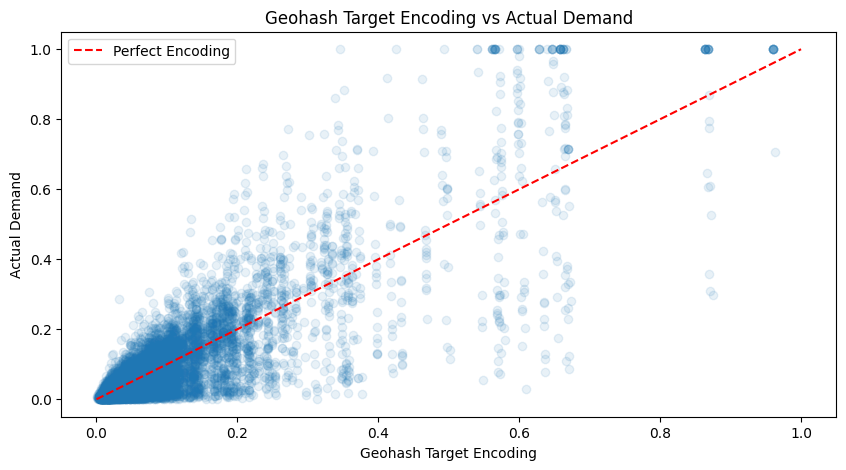

In [7]:
import matplotlib.pyplot as plt

# Sample 10000 rows randomly
np.random.seed(42)
sample_df = train_df.sample(n=min(10000, len(train_df)))

plt.figure(figsize=(10, 5))
plt.scatter(sample_df['geohash_target_enc'], sample_df['demand'], alpha=0.1)

# Add reference line
max_val = max(sample_df['geohash_target_enc'].max(), sample_df['demand'].max())
min_val = min(sample_df['geohash_target_enc'].min(), sample_df['demand'].min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Encoding')

plt.title('Geohash Target Encoding vs Actual Demand')
plt.xlabel('Geohash Target Encoding')
plt.ylabel('Actual Demand')
plt.legend()

# Save plot
plot_path = os.path.join(BIVARIATE_PLOTS_DIR, 'geohash_encoding_quality.png')
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

### Conclusion

The scatter plot shows the relationship between the actual demand and the geohash target encoding. The red dashed line represents where perfectly predictive encoding would fall.
The clustering of points around the red diagonal illustrates how tightly the encoding tracks the actual demand. It shows that the encoding is a strong predictor, while the spread indicates the variance present at individual geohash locations.

In [8]:
# Drop raw geohash and prefix columns
train_df = train_df.drop(columns=['geohash', 'geohash_prefix'])
test_df = test_df.drop(columns=['geohash', 'geohash_prefix'])

print("Columns after dropping:")
print("Train:", train_df.columns.tolist())
print("Test:", test_df.columns.tolist())

Columns after dropping:
Train: ['day', 'demand', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'hour', 'minute', 'road_type_ord', 'weather_severity', 'latitude', 'longitude', 'geohash_target_enc', 'geohash_prefix_enc']
Test: ['day', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'hour', 'minute', 'road_type_ord', 'weather_severity', 'latitude', 'longitude', 'geohash_prefix_enc', 'geohash_target_enc']


In [9]:
# Save
train_path = os.path.join(PROC_DIR, 'train_step04.csv')
test_path = os.path.join(PROC_DIR, 'test_step04.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Train saved to {train_path} with shape {train_df.shape}")
print(f"Test saved to {test_path} with shape {test_df.shape}")

Train saved to C:\traffic-demand-final\pipelining\processed\train_step04.csv with shape (77299, 14)
Test saved to C:\traffic-demand-final\pipelining\processed\test_step04.csv with shape (41778, 13)


### Step 04 Complete — What Was Done

- Used pygeohash to decode string geohashes into their central point latitude and longitude. New columns `latitude` and `longitude` were created.
- Created `geohash_prefix` by extracting the first `GEOHASH_PREFIX_LEN` characters to show how unique geohash cells group into larger prefix groups.
- Implemented Leave-One-Out (LOO) target encoding for the training set to prevent data leakage by taking the mean of other observations in the same geohash.
- Computed simple mean encoding to apply safely on the unseen test set, which is correct because test data cannot be used to inform the model training.
- Established a three-level fallback strategy for target encoding on the test set: exact geohash mean, then prefix mean, then overall global mean.
- Saved visualisations comparing encoding quality against actual demand to `BIVARIATE_PLOTS_DIR`.
- Dropped the raw `geohash` and `geohash_prefix` string columns.
- Saved updated datasets to `train_step04.csv` and `test_step04.csv` in the processed data directory.
- The next step involves further feature engineering, temporal encodings, or preparing the dataset for model training.